In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA_PATH = "field wise yield dataset Hanthana.xlsx"
TEST_SIZE = 12
VAL_SIZE  = 12

PQR_GRID  = [(1,1,1), (0,1,1)]
SEAS_GRID = [(1,0,1,12), (0,1,1,12)]
MAXITER   = 80

USE_EXOG  = True
USE_LOG1P = True

ZERO_EPS = 5.0
CLIP_Q   = 0.99

PROD_PCTL = 40     
APE_CAP   = 100.0   

df = pd.read_excel(DATA_PATH)

# Support both full month names ("January") and abbreviated ("Jan")
month_map_full = {m: i for i, m in enumerate(
    ["January","February","March","April","May","June",
     "July","August","September","October","November","December"], start=1
)}
month_map_abbr = {m: i for i, m in enumerate(
    ["Jan","Feb","Mar","Apr","May","Jun",
     "Jul","Aug","Sep","Oct","Nov","Dec"], start=1
)}
month_map = {**month_map_full, **month_map_abbr}

df["Division"] = df["Division"].astype(str).str.strip().str.title()
df["Month"]    = df["Month"].astype(str).str.strip().str.title()
df["Month_num"] = df["Month"].map(month_map)

df["date"] = pd.to_datetime(dict(year=df["Year"].astype(int),
                                 month=df["Month_num"].astype(int),
                                 day=1), errors="coerce")

# Use str conversion (not int) to handle alphanumeric Field_IDs like "1 A", "NC 4"
df["FieldKey"] = df["Division"] + "_" + df["Field_ID"].astype(str).str.strip()

for c in ["Yield_Total","Rainfall_mm","Wet_Days_Count","Plucking_Rounds","Fertilizer_percentage","Fertilizer_Ratio"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["FieldKey","date","Yield_Total"]).sort_values(["FieldKey","date"]).reset_index(drop=True)
print("fields:", df["FieldKey"].nunique(), "rows:", df.shape[0])
df.head()


fields: 65 rows: 8225


,Division,Field_ID,Year,Month,Planting_Year,Bush age,Pruning_Year,After_Pruning_Age_Months,After_Pruning_Age_YearGroup,Propagation_Method,...,Wet_Days_Count,Fertilizer_mixture,Fertilizer_percentage,Fertilizer_Ratio,Plucking_Rounds,Soil_PH,Yield_Total,Month_num,date,FieldKey
0,Galaha,1 A,2016,Mar,1994,22,2016-03-01,1,1,VP,...,6,NaN,0,0.00,0,4.71,0.0,3,2016-03-01,Galaha_1 A
1,Galaha,1 A,2016,Apr,1994,22,2016-03-01,2,1,VP,...,2,NaN,0,0.00,0,4.71,0.0,4,2016-04-01,Galaha_1 A
2,Galaha,1 A,2016,May,1994,22,2016-03-01,3,1,VP,...,30,NaN,0,0.00,0,4.71,0.0,5,2016-05-01,Galaha_1 A
3,Galaha,1 A,2016,Jun,1994,22,2016-03-01,4,1,VP,...,1,U-1145,70,16.12,5,4.71,173.0,6,2016-06-01,Galaha_1 A
4,Galaha,1 A,2016,Jul,1994,22,2016-03-01,5,1,VP,...,6,U-330,90,16.71,4,4.71,75.0,7,2016-07-01,Galaha_1 A


In [2]:
def add_features(g):
    g = g.sort_values("date").copy()

    g["is_zero_yield"] = (g["Yield_Total"] == 0).astype(int)

    ms = []
    last = None
    for i, v in enumerate(g["is_zero_yield"].values):
        if v == 1:
            last = i
            ms.append(0)
        else:
            ms.append(i - last if last is not None else 999)
    g["months_since_zero"] = ms

    covs = ["Rainfall_mm","Wet_Days_Count","Plucking_Rounds","Fertilizer_percentage","Fertilizer_Ratio"]
    for c in covs:
        for L in [1,2,3]:
            g[f"{c}_lag_{L}"] = g[c].shift(L)

    return g

EXOG_COLS = [
    "Rainfall_mm_lag_1","Rainfall_mm_lag_2","Rainfall_mm_lag_3",
    "Wet_Days_Count_lag_1","Wet_Days_Count_lag_2","Wet_Days_Count_lag_3",
    "Plucking_Rounds_lag_1","Plucking_Rounds_lag_2","Plucking_Rounds_lag_3",
    "Fertilizer_percentage_lag_1","Fertilizer_percentage_lag_2","Fertilizer_percentage_lag_3",
    "Fertilizer_Ratio_lag_1","Fertilizer_Ratio_lag_2","Fertilizer_Ratio_lag_3",
    "is_zero_yield","months_since_zero"
]

In [3]:
def mae_rmse_mape(y_true, y_pred, prod_min=0.0, ape_cap=100.0):
    """
    Returns ONLY 3 metrics.
    MAPE is pruning-safe:
      - uses only months where y_true >= prod_min and y_true > 0
      - caps per-month APE to avoid one month exploding the mean
    """
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]

    if len(y_true) == 0:
        return np.nan, np.nan, np.nan

    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    prod = (y_true > 0) & (y_true >= prod_min)
    if prod.sum() == 0:
        mape = np.nan
    else:
        ape = np.abs((y_true[prod] - y_pred[prod]) / np.abs(y_true[prod])) * 100
        ape = np.clip(ape, 0, ape_cap)   # cap outliers
        mape = float(np.mean(ape))

    return mae, rmse, mape

In [4]:
def fit_eval_one_field(g, order, seas):
    g = add_features(g)

    full_idx = pd.date_range(g["date"].min(), g["date"].max(), freq="MS")
    g = g.set_index("date").reindex(full_idx).reset_index().rename(columns={"index":"date"})

    # usable rows
    if USE_EXOG:
        d = g.dropna(subset=["Yield_Total"] + EXOG_COLS).copy()
    else:
        d = g.dropna(subset=["Yield_Total"]).copy()

    if len(d) < (TEST_SIZE + VAL_SIZE + 24):
        return None

    d = d.sort_values("date")
    val  = d.iloc[-(TEST_SIZE+VAL_SIZE):-TEST_SIZE].copy()
    train= d.iloc[:-(TEST_SIZE+VAL_SIZE)].copy()

    y_train = train["Yield_Total"].values
    y_val   = val["Yield_Total"].values

    # productive threshold from TRAIN only
    pos = y_train[y_train > 0]
    prod_min = float(np.nanpercentile(pos, PROD_PCTL)) if len(pos) else 0.0

    y_train_t = np.log1p(y_train) if USE_LOG1P else y_train
    y_train_series = pd.Series(y_train_t, index=pd.DatetimeIndex(train["date"]))

    X_train = train[EXOG_COLS].to_numpy(float) if USE_EXOG else None
    X_val   = val[EXOG_COLS].to_numpy(float)   if USE_EXOG else None

    try:
        model = SARIMAX(
            endog=y_train_series,
            exog=X_train,
            order=order,
            seasonal_order=seas,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=MAXITER)

        pred_t = model.get_forecast(steps=len(val), exog=X_val).predicted_mean.values
        pred = np.expm1(pred_t) if USE_LOG1P else pred_t

        pred = np.clip(pred, 0, None)
        pred[pred < ZERO_EPS] = 0.0

        cap = np.nanquantile(y_train, CLIP_Q)
        if np.isfinite(cap) and cap > 0:
            pred = np.minimum(pred, cap)

        mae, rmse, mape = mae_rmse_mape(y_val, pred, prod_min=prod_min, ape_cap=APE_CAP)
        return {"order": order, "seas": seas, "score_mape": mape}

    except Exception:
        return None


def select_best_model_for_field(g):
    best = None
    for order in PQR_GRID:
        for seas in SEAS_GRID:
            r = fit_eval_one_field(g, order, seas)
            if r is None or not np.isfinite(r["score_mape"]):
                continue
            if (best is None) or (r["score_mape"] < best["score_mape"]):
                best = r
    return best


def refit_and_test(g, order, seas):
    g = add_features(g)

    full_idx = pd.date_range(g["date"].min(), g["date"].max(), freq="MS")
    g = g.set_index("date").reindex(full_idx).reset_index().rename(columns={"index":"date"})

    if USE_EXOG:
        d = g.dropna(subset=["Yield_Total"] + EXOG_COLS).copy()
    else:
        d = g.dropna(subset=["Yield_Total"]).copy()

    d = d.sort_values("date")
    if len(d) < (TEST_SIZE + 36):
        return None

    test  = d.iloc[-TEST_SIZE:].copy()
    train = d.iloc[:-TEST_SIZE].copy()

    y_train = train["Yield_Total"].values
    y_test  = test["Yield_Total"].values

    # productive threshold from TRAIN only
    pos = y_train[y_train > 0]
    prod_min = float(np.nanpercentile(pos, PROD_PCTL)) if len(pos) else 0.0

    y_train_t = np.log1p(y_train) if USE_LOG1P else y_train
    y_train_series = pd.Series(y_train_t, index=pd.DatetimeIndex(train["date"]))

    X_train = train[EXOG_COLS].to_numpy(float) if USE_EXOG else None
    X_test  = test[EXOG_COLS].to_numpy(float)  if USE_EXOG else None

    try:
        model = SARIMAX(
            endog=y_train_series,
            exog=X_train,
            order=order,
            seasonal_order=seas,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=MAXITER)

        pred_t = model.get_forecast(steps=len(test), exog=X_test).predicted_mean.values
        pred = np.expm1(pred_t) if USE_LOG1P else pred_t

        pred = np.clip(pred, 0, None)
        pred[pred < ZERO_EPS] = 0.0

        cap = np.nanquantile(y_train, CLIP_Q)
        if np.isfinite(cap) and cap > 0:
            pred = np.minimum(pred, cap)

        mae, rmse, mape = mae_rmse_mape(y_test, pred, prod_min=prod_min, ape_cap=APE_CAP)
        return mae, rmse, mape

    except Exception:
        return None

In [5]:
fields = sorted(df["FieldKey"].unique())
rows = []

for fk in fields:
    g = df[df["FieldKey"] == fk][[
        "date","Yield_Total",
        "Rainfall_mm","Wet_Days_Count","Plucking_Rounds",
        "Fertilizer_percentage","Fertilizer_Ratio"
    ]].copy()

    best = select_best_model_for_field(g)
    if best is None:
        rows.append([fk, None, None, np.nan, np.nan, np.nan])
        continue

    out = refit_and_test(g, best["order"], best["seas"])
    if out is None:
        rows.append([fk, best["order"], best["seas"], np.nan, np.nan, np.nan])
        continue

    mae, rmse, mape = out
    rows.append([fk, best["order"], best["seas"], mae, rmse, mape])

metrics_simple = pd.DataFrame(rows, columns=["FieldKey","order","seas","MAE","RMSE","MAPE"])
display(metrics_simple.sort_values("MAPE"))

metrics_simple.to_excel("metrics_fields_with_configs.xlsx", index=False)
metrics_simple.to_csv("metrics_fields_with_configs.csv", index=False)
print("Saved -> metrics_fields_with_configs.xlsx / .csv")

C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No fre

,FieldKey,order,seas,MAE,RMSE,MAPE
7,Galaha_3,"(0, 1, 1)","(1, 0, 1, 12)",49.886913,71.403938,4.968248
21,Kitoolmoola_32,"(1, 1, 1)","(0, 1, 1, 12)",96.582212,147.948749,13.305082
51,Ooragalla_28,"(1, 1, 1)","(1, 0, 1, 12)",95.008113,110.926911,18.319714
28,Kitoolmoola_NC 6,"(0, 1, 1)","(1, 0, 1, 12)",84.269647,108.706061,19.567186
23,Kitoolmoola_NC 1,"(1, 1, 1)","(1, 0, 1, 12)",63.200630,70.747919,19.863676
...,...,...,...,...,...,...
47,Ooragalla_19,"(1, 1, 1)","(0, 1, 1, 12)",253.922626,274.787661,71.007731
49,Ooragalla_26,"(1, 1, 1)","(0, 1, 1, 12)",126.758225,159.079594,81.382593
5,Galaha_2 A,"(1, 1, 1)","(0, 1, 1, 12)",281.380749,291.354881,83.958307
4,Galaha_2,"(0, 1, 1)","(1, 0, 1, 12)",66.966334,90.125975,NaN


Saved -> metrics_fields_with_configs.xlsx / .csv


In [6]:
ok = metrics_simple.dropna(subset=["MAE","RMSE","MAPE"]).copy()

print({
    "Overall_MAE": float(ok["MAE"].mean()),
    "Overall_RMSE": float(ok["RMSE"].mean()),
    "Overall_MAPE": float(ok["MAPE"].mean())
})

{'Overall_MAE': 143.31092927510775, 'Overall_RMSE': 174.38547979036036, 'Overall_MAPE': 37.831241963286}


In [7]:
import matplotlib.pyplot as plt

def _prepare_field_d(df, fk):
    g = df[df["FieldKey"] == fk][[
        "date","Yield_Total",
        "Rainfall_mm","Wet_Days_Count","Plucking_Rounds",
        "Fertilizer_percentage","Fertilizer_Ratio"
    ]].copy()

    g = add_features(g)

    full_idx = pd.date_range(g["date"].min(), g["date"].max(), freq="MS")
    g = g.set_index("date").reindex(full_idx).reset_index().rename(columns={"index":"date"})

    if USE_EXOG:
        d = g.dropna(subset=["Yield_Total"] + EXOG_COLS).copy()
    else:
        d = g.dropna(subset=["Yield_Total"]).copy()

    d = d.sort_values("date").reset_index(drop=True)
    return d

def _postprocess_pred(pred, y_train):
    pred = np.asarray(pred, float)
    pred = np.clip(pred, 0, None)
    pred[pred < ZERO_EPS] = 0.0

    cap = np.nanquantile(y_train, CLIP_Q)
    if np.isfinite(cap) and cap > 0:
        pred = np.minimum(pred, cap)
    return pred

def sarimax_test_actual_vs_pred(df, fk, order, seas, title_prefix=""):
    d = _prepare_field_d(df, fk)
    if len(d) < (TEST_SIZE + 36):
        print(f"Not enough rows for {fk}. rows={len(d)}")
        return

    test  = d.iloc[-TEST_SIZE:].copy()
    train = d.iloc[:-TEST_SIZE].copy()

    y_train = train["Yield_Total"].values
    y_test  = test["Yield_Total"].values

    pos = y_train[y_train > 0]
    prod_min = float(np.nanpercentile(pos, PROD_PCTL)) if len(pos) else 0.0

    y_train_t = np.log1p(y_train) if USE_LOG1P else y_train
    y_train_series = pd.Series(y_train_t, index=pd.DatetimeIndex(train["date"]))

    X_train = train[EXOG_COLS].to_numpy(float) if USE_EXOG else None
    X_test  = test[EXOG_COLS].to_numpy(float)  if USE_EXOG else None

    model = SARIMAX(
        endog=y_train_series,
        exog=X_train,
        order=order,
        seasonal_order=seas,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=MAXITER)

    pred_t = model.get_forecast(steps=len(test), exog=X_test).predicted_mean.values
    pred   = np.expm1(pred_t) if USE_LOG1P else pred_t
    pred   = _postprocess_pred(pred, y_train)

    mae, rmse, mape = mae_rmse_mape(y_test, pred, prod_min=prod_min, ape_cap=APE_CAP)

    # Plot (Test set only)
    plt.figure(figsize=(12,4))
    plt.plot(test["date"], y_test, label="Actual (Test)", linewidth=2)
    plt.plot(test["date"], pred,  label="Predicted (Test)", linewidth=2)
    plt.title(f"{title_prefix}{fk} | SARIMAX{order}x{seas} | Monthly Actual vs Predicted (Test)")
    plt.xlabel("Month")
    plt.ylabel("Yield_Total")
    plt.legend()
    plt.tight_layout()
    plt.show()

    caption = (
        f"{fk}: Monthly actual vs predicted yield using SARIMAX{order}x{seas}. "
        f"Test-set: MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}% "
        f"(MAPE uses prod_min={prod_min:.2f}, cap={APE_CAP:.0f}%)."
    )
    print(caption)


def rolling_sarimax_forecast(df, fk, order, seas, test_size=12):
    d = _prepare_field_d(df, fk)
    if len(d) < (test_size + 36):
        print(f"Not enough rows for {fk}. rows={len(d)}")
        return None

    split = len(d) - test_size
    y_train = d.loc[:split-1, "Yield_Total"].values
    y_test  = d.loc[split:,   "Yield_Total"].values
    idx_test= d.loc[split:,   "date"]

    pos = y_train[y_train > 0]
    prod_min = float(np.nanpercentile(pos, PROD_PCTL)) if len(pos) else 0.0

    preds = []

    for i in range(test_size):
        hist_end = split + i  # exclusive end index for history slice
        hist = d.iloc[:hist_end].copy()
        nxt  = d.iloc[hist_end:hist_end+1].copy()

        y_hist = hist["Yield_Total"].values
        y_hist_t = np.log1p(y_hist) if USE_LOG1P else y_hist
        y_hist_series = pd.Series(y_hist_t, index=pd.DatetimeIndex(hist["date"]))

        X_hist = hist[EXOG_COLS].to_numpy(float) if USE_EXOG else None
        X_nxt  = nxt[EXOG_COLS].to_numpy(float)  if USE_EXOG else None

        try:
            res = SARIMAX(
                endog=y_hist_series,
                exog=X_hist,
                order=order,
                seasonal_order=seas,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit(disp=False, maxiter=MAXITER)

            p_t = res.get_forecast(steps=1, exog=X_nxt).predicted_mean.values[0]
            p   = np.expm1(p_t) if USE_LOG1P else p_t
            p   = _postprocess_pred([p], y_hist)[0]
        except Exception:
            p = np.nan

        preds.append(p)

    y_pred_roll = pd.Series(preds, index=pd.DatetimeIndex(idx_test))

    
    mae, rmse, mape = mae_rmse_mape(y_test, y_pred_roll.values, prod_min=prod_min, ape_cap=APE_CAP)
    return d, pd.Series(y_test, index=pd.DatetimeIndex(idx_test)), y_pred_roll, (mae, rmse, mape, prod_min)


def plot_rolling_sarimax(df, fk, order, seas, test_size=12):
    out = rolling_sarimax_forecast(df, fk, order, seas, test_size=test_size)
    if out is None:
        return
    d, y_test, y_pred_roll, (mae, rmse, mape, prod_min) = out

    plt.figure(figsize=(12,4))
    plt.plot(d["date"], d["Yield_Total"], label="Full series (history)", linewidth=1)
    plt.plot(y_test.index, y_test.values, label="Test (actual)", linewidth=2)
    plt.plot(y_pred_roll.index, y_pred_roll.values, label="Test (rolling 1-step)", linewidth=2)
    plt.title(f"{fk} | Rolling 1-step-ahead Forecast on Test Set (SARIMAX{order}x{seas})")
    plt.xlabel("Month")
    plt.ylabel("Yield_Total")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(
        f"{fk}: Rolling SARIMAX{order}x{seas} on test. "
        f"MAE={mae:.2f}, RMSE={rmse:.2f}, MAPE={mape:.2f}% (prod_min={prod_min:.2f})."
    )


def plot_sarimax_in_sample_fit(df, fk, order, seas):
    d = _prepare_field_d(df, fk)
    if len(d) < 36:
        print(f"Not enough rows for {fk}. rows={len(d)}")
        return

    y = d["Yield_Total"].values
    y_t = np.log1p(y) if USE_LOG1P else y
    y_series = pd.Series(y_t, index=pd.DatetimeIndex(d["date"]))

    X = d[EXOG_COLS].to_numpy(float) if USE_EXOG else None

    res = SARIMAX(
        endog=y_series,
        exog=X,
        order=order,
        seasonal_order=seas,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, maxiter=MAXITER)

    # 1-step-ahead in-sample predictions (dynamic=False)
    pred_t = res.get_prediction(start=d["date"].iloc[1], end=d["date"].iloc[-1], dynamic=False).predicted_mean
    fitted = np.expm1(pred_t.values) if USE_LOG1P else pred_t.values
    fitted = _postprocess_pred(fitted, y_train=y)  # optional, keeps consistent caps/zeros
    fitted = pd.Series(fitted, index=pred_t.index)

    plt.figure(figsize=(12,4))
    plt.plot(d["date"], y, label="Actual", linewidth=1.5)
    plt.plot(fitted.index, fitted.values, label="SARIMAX fitted (1-step)", linewidth=2)
    plt.title(f"{fk} | SARIMAX{order}x{seas} In-sample 1-step Fit")
    plt.xlabel("Month")
    plt.ylabel("Yield_Total")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [8]:

fk = metrics_simple.dropna(subset=["MAPE"]).sort_values("MAPE").iloc[0]["FieldKey"]

fk

'Galaha_3'

In [9]:
g_fk = df[df["FieldKey"] == fk][[
    "date","Yield_Total",
    "Rainfall_mm","Wet_Days_Count","Plucking_Rounds",
    "Fertilizer_percentage","Fertilizer_Ratio"
]].copy()

best = select_best_model_for_field(g_fk)
best

C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No fre

{'order': (0, 1, 1), 'seas': (1, 0, 1, 12), 'score_mape': 32.96720863882313}

C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


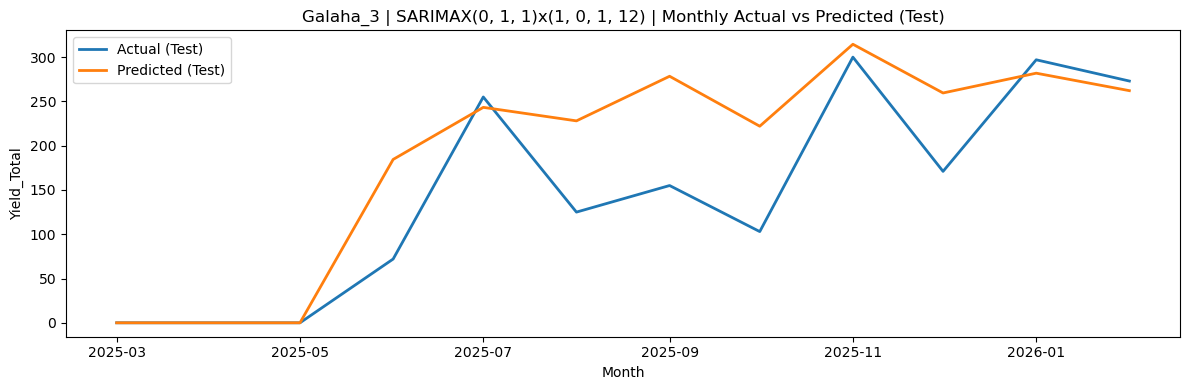

Galaha_3: Monthly actual vs predicted yield using SARIMAX(0, 1, 1)x(1, 0, 1, 12). Test-set: MAE=49.89, RMSE=71.40, MAPE=4.97% (MAPE uses prod_min=279.40, cap=100%).


In [10]:
sarimax_test_actual_vs_pred(df, fk, best["order"], best["seas"])

C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No fre

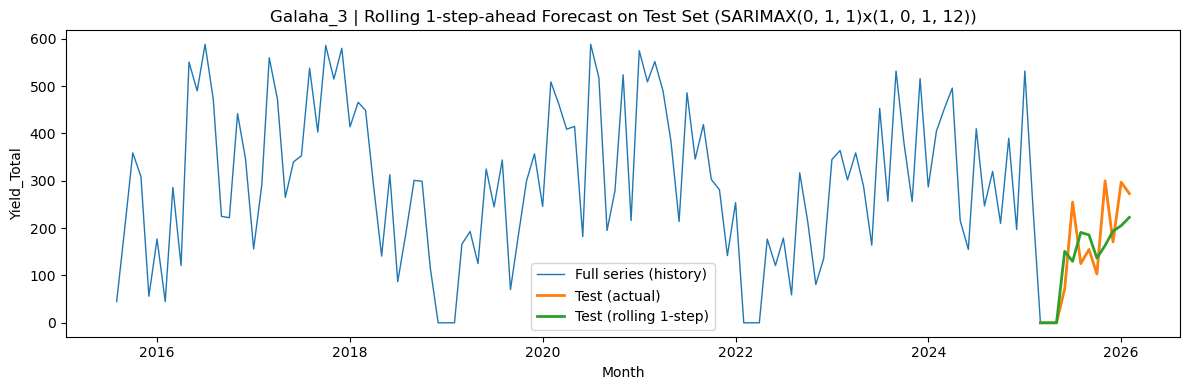

Galaha_3: Rolling SARIMAX(0, 1, 1)x(1, 0, 1, 12) on test. MAE=52.97, RMSE=69.79, MAPE=38.22% (prod_min=279.40).


In [11]:
plot_rolling_sarimax(df, fk, best["order"], best["seas"], test_size=TEST_SIZE)

C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


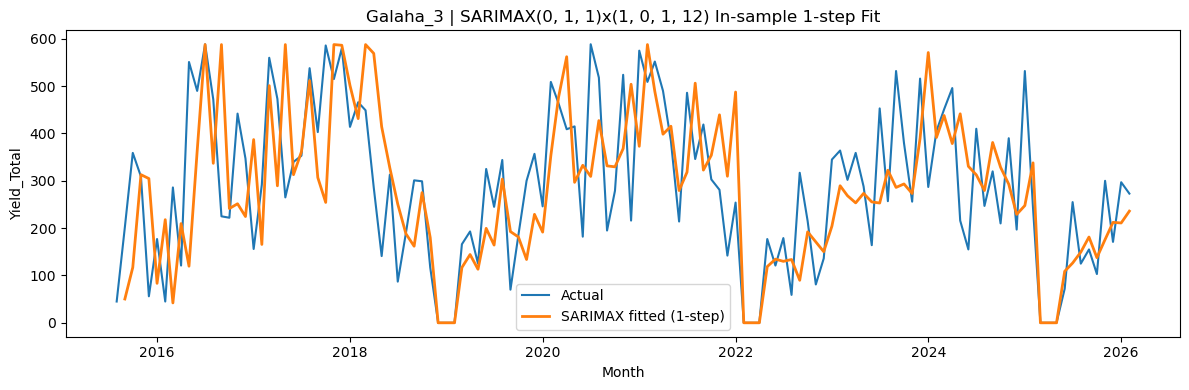

In [12]:
plot_sarimax_in_sample_fit(df, fk, best["order"], best["seas"])

In [13]:
import os, json, shutil
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX, SARIMAXResults

SAVE_DIR = Path("sarimax_models_fields")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

def _safe_name(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in ("_", "-", ".") else "_" for ch in str(s))

saved = 0
index_rows = []

for _, r in metrics_simple.dropna(subset=["order","seas"]).iterrows():
    fk = r["FieldKey"]
    order = tuple(r["order"]) if isinstance(r["order"], (list, tuple)) else eval(str(r["order"]))
    seas  = tuple(r["seas"])  if isinstance(r["seas"],  (list, tuple)) else eval(str(r["seas"]))

    try:
        d = _prepare_field_d(df, fk)  
        if len(d) < 36:
            index_rows.append({"FieldKey": fk, "status": "skip_not_enough_rows"})
            continue

        y = d["Yield_Total"].values
        y_t = np.log1p(y) if USE_LOG1P else y
        y_series = pd.Series(y_t, index=pd.DatetimeIndex(d["date"]))

        X = d[EXOG_COLS].to_numpy(float) if USE_EXOG else None

        res = SARIMAX(
            endog=y_series,
            exog=X,
            order=order,
            seasonal_order=seas,
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False, maxiter=MAXITER)

        fname = _safe_name(fk)
        model_path = SAVE_DIR / f"{fname}_sarimax.pkl"
        meta_path  = SAVE_DIR / f"{fname}_meta.json"

        res.save(model_path)

        cap_val = float(np.nanquantile(y, CLIP_Q)) if np.isfinite(np.nanquantile(y, CLIP_Q)) else None
        meta = {
            "FieldKey": fk,
            "order": order,
            "seasonal_order": seas,
            "USE_EXOG": USE_EXOG,
            "EXOG_COLS": EXOG_COLS,
            "USE_LOG1P": USE_LOG1P,
            "ZERO_EPS": float(ZERO_EPS),
            "CLIP_Q": float(CLIP_Q),
            "CAP_VALUE": cap_val,
            "data_start": str(d["date"].min().date()),
            "data_end": str(d["date"].max().date()),
            "n_obs": int(len(d)),
        }
        meta_path.write_text(json.dumps(meta, indent=2))

        index_rows.append({"FieldKey": fk, "status": "saved", "pkl": str(model_path), "meta": str(meta_path)})
        saved += 1

    except Exception as e:
        index_rows.append({"FieldKey": fk, "status": "error", "error": str(e)})

pd.DataFrame(index_rows).to_csv(SAVE_DIR / "models_index.csv", index=False)
print(f" Saved {saved} models into: {SAVE_DIR.resolve()}")

zip_name = shutil.make_archive("sarimax_models_fields", "zip", SAVE_DIR)
print(f" Zipped -> {zip_name}")

C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\User\anaconda3\envs\ml_env\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No fre

 Saved 65 models into: C:\Users\User\Finaaaaal model-Copy1-Copy1\sarimax_models_fields
 Zipped -> C:\Users\User\Finaaaaal model-Copy1-Copy1\sarimax_models_fields.zip


In [14]:
# ============================================================
# CELL 1: Forecast next month for all fields using saved models
# ============================================================

import json
from pathlib import Path
from IPython.display import display
from statsmodels.tsa.statespace.sarimax import SARIMAXResults

MODEL_DIR = Path("sarimax_models_fields")

EXOG_BASE = [
    "Rainfall_mm",
    "Wet_Days_Count",
    "Plucking_Rounds",
    "Fertilizer_percentage",
    "Fertilizer_Ratio"
]

def _safe_name(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in ("_", "-", ".") else "_" for ch in str(s))

def build_field_history(df, fieldkey):
    """
    Raw monthly history for one field, reindexed to monthly start,
    then add_features() is applied.
    """
    g = df[df["FieldKey"] == fieldkey][["date", "Yield_Total"] + EXOG_BASE].copy()
    if g.empty:
        raise ValueError(f"No rows found for FieldKey={fieldkey}")

    g["date"] = pd.to_datetime(g["date"], errors="coerce")
    g = g.dropna(subset=["date"]).sort_values("date").drop_duplicates(subset="date", keep="last")

    for c in ["Yield_Total"] + EXOG_BASE:
        g[c] = pd.to_numeric(g[c], errors="coerce")

    full_idx = pd.date_range(g["date"].min(), g["date"].max(), freq="MS")
    g = g.set_index("date").reindex(full_idx).reset_index().rename(columns={"index": "date"})

    g = add_features(g)
    return g.reset_index(drop=True)

def load_saved_model_and_meta(fieldkey, model_dir=MODEL_DIR):
    fname = _safe_name(fieldkey)

    model_path = model_dir / f"{fname}_sarimax.pkl"
    meta_path  = model_dir / f"{fname}_meta.json"

    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")
    if not meta_path.exists():
        raise FileNotFoundError(f"Meta file not found: {meta_path}")

    model = SARIMAXResults.load(model_path)
    meta = json.loads(meta_path.read_text())

    return model, meta

def build_next_exog_auto(hist):
    """
    Build exog for next month automatically from latest available history.
    lag_1 = last known month
    lag_2 = month before
    lag_3 = two months before
    """
    hist = hist.sort_values("date").reset_index(drop=True)
    last_row = hist.iloc[-1]

    exog_next = {
        "is_zero_yield": float(last_row["is_zero_yield"]),
        "months_since_zero": float(last_row["months_since_zero"]),
    }

    for c in EXOG_BASE:
        s = pd.to_numeric(hist[c], errors="coerce").dropna()
        if len(s) < 3:
            raise ValueError(f"Not enough non-missing history for {c}. Need at least 3 values.")
        exog_next[f"{c}_lag_1"] = float(s.iloc[-1])
        exog_next[f"{c}_lag_2"] = float(s.iloc[-2])
        exog_next[f"{c}_lag_3"] = float(s.iloc[-3])

    X_next = pd.DataFrame([exog_next], columns=EXOG_COLS).astype(float)
    return X_next

def postprocess_value(x, zero_eps=5.0, cap_value=None):
    x = float(x)
    x = max(0.0, x)
    if x < zero_eps:
        x = 0.0
    if cap_value is not None and np.isfinite(cap_value) and cap_value > 0:
        x = min(x, float(cap_value))
    return x

def forecast_next_month_saved(fieldkey):
    model, meta = load_saved_model_and_meta(fieldkey)
    hist = build_field_history(df, fieldkey)

    X_next = build_next_exog_auto(hist)
    fc = model.get_forecast(steps=1, exog=X_next)

    pred_t = float(np.asarray(fc.predicted_mean)[0])

    ci = fc.conf_int(alpha=0.05)
    if hasattr(ci, "iloc"):
        lo_t = float(ci.iloc[0, 0])
        hi_t = float(ci.iloc[0, 1])
    else:
        lo_t = float(ci[0, 0])
        hi_t = float(ci[0, 1])

    use_log1p = bool(meta.get("USE_LOG1P", True))
    zero_eps  = float(meta.get("ZERO_EPS", 5.0))
    cap_value = meta.get("CAP_VALUE", None)

    if use_log1p:
        pred = np.expm1(pred_t)
        lo   = np.expm1(lo_t)
        hi   = np.expm1(hi_t)
    else:
        pred = pred_t
        lo   = lo_t
        hi   = hi_t

    pred = postprocess_value(pred, zero_eps=zero_eps, cap_value=cap_value)
    lo   = postprocess_value(lo,   zero_eps=zero_eps, cap_value=cap_value)
    hi   = postprocess_value(hi,   zero_eps=zero_eps, cap_value=cap_value)

    last_date = pd.to_datetime(hist["date"].max()).date()
    next_date = (pd.to_datetime(hist["date"].max()) + pd.offsets.MonthBegin(1)).date()

    return {
        "FieldKey": fieldkey,
        "Last_History_Month": last_date,
        "Next_Month": next_date,
        "Predicted_Yield_Total": round(pred, 2),
        "Lower_95": round(lo, 2),
        "Upper_95": round(hi, 2),
        "order": tuple(meta.get("order", [])),
        "seasonal_order": tuple(meta.get("seasonal_order", []))
    }

# ---- Forecast all fields ----
pred_rows = []

for fk in sorted(df["FieldKey"].dropna().unique()):
    try:
        pred_rows.append(forecast_next_month_saved(fk))
    except Exception as e:
        pred_rows.append({
            "FieldKey": fk,
            "Last_History_Month": None,
            "Next_Month": None,
            "Predicted_Yield_Total": np.nan,
            "Lower_95": np.nan,
            "Upper_95": np.nan,
            "order": None,
            "seasonal_order": None,
            "error": str(e)
        })

pred_next_df = pd.DataFrame(pred_rows).sort_values("FieldKey").reset_index(drop=True)

display(pred_next_df.head(20))

pred_next_df.to_csv("field_next_month_predictions_from_saved_models.csv", index=False)
pred_next_df.to_excel("field_next_month_predictions_from_saved_models.xlsx", index=False)

print("Saved -> field_next_month_predictions_from_saved_models.csv / .xlsx")

,FieldKey,Last_History_Month,Next_Month,Predicted_Yield_Total,Lower_95,Upper_95,order,seasonal_order
0,Galaha_1 A,2026-02-01,2026-03-01,335.62,131.91,586.32,"(0, 1, 1)","(1, 0, 1, 12)"
1,Galaha_1 B,2026-02-01,2026-03-01,303.51,132.07,554.77,"(0, 1, 1)","(1, 0, 1, 12)"
2,Galaha_12,2026-02-01,2026-03-01,309.12,133.58,565.16,"(0, 1, 1)","(1, 0, 1, 12)"
3,Galaha_16,2026-02-01,2026-03-01,237.95,108.94,518.33,"(0, 1, 1)","(1, 0, 1, 12)"
4,Galaha_2,2026-02-01,2026-03-01,129.74,56.84,294.54,"(0, 1, 1)","(1, 0, 1, 12)"
5,Galaha_2 A,2026-02-01,2026-03-01,130.06,53.23,315.76,"(1, 1, 1)","(0, 1, 1, 12)"
6,Galaha_2 B,2026-02-01,2026-03-01,235.03,102.63,536.57,"(0, 1, 1)","(1, 0, 1, 12)"
7,Galaha_3,2026-02-01,2026-03-01,242.48,102.11,573.92,"(0, 1, 1)","(1, 0, 1, 12)"
8,Hantane Top_2 A,2026-02-01,2026-03-01,416.32,188.19,573.24,"(1, 1, 1)","(1, 0, 1, 12)"
9,Hantane Top_3,2026-02-01,2026-03-01,328.60,143.77,589.14,"(1, 1, 1)","(1, 0, 1, 12)"


Saved -> field_next_month_predictions_from_saved_models.csv / .xlsx


In [15]:
# ============================================================
# SARIMAX UI: fields ending at latest data month, predict next month
# ============================================================

import json
from pathlib import Path
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, clear_output
from statsmodels.tsa.statespace.sarimax import SARIMAXResults

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
MODEL_DIR = Path("sarimax_models_fields")
# Dynamically determine the last date from the loaded dataset
EXPECTED_LAST_DATE = df.groupby("FieldKey")["date"].max().max().normalize()
PREDICT_DATE = EXPECTED_LAST_DATE + pd.offsets.MonthBegin(1)

EXOG_BASE = [
    "Rainfall_mm",
    "Wet_Days_Count",
    "Plucking_Rounds",
    "Fertilizer_percentage",
    "Fertilizer_Ratio"
]

EXOG_COLS = [
    "Rainfall_mm_lag_1","Rainfall_mm_lag_2","Rainfall_mm_lag_3",
    "Wet_Days_Count_lag_1","Wet_Days_Count_lag_2","Wet_Days_Count_lag_3",
    "Plucking_Rounds_lag_1","Plucking_Rounds_lag_2","Plucking_Rounds_lag_3",
    "Fertilizer_percentage_lag_1","Fertilizer_percentage_lag_2","Fertilizer_percentage_lag_3",
    "Fertilizer_Ratio_lag_1","Fertilizer_Ratio_lag_2","Fertilizer_Ratio_lag_3",
    "is_zero_yield","months_since_zero"
]

# ------------------------------------------------------------
# HELPERS
# ------------------------------------------------------------
def _safe_name(s: str) -> str:
    return "".join(ch if ch.isalnum() or ch in ("_", "-", ".") else "_" for ch in str(s))

def add_features(g):
    g = g.sort_values("date").copy()

    g["is_zero_yield"] = (g["Yield_Total"] == 0).astype(int)

    ms = []
    last = None
    for i, v in enumerate(g["is_zero_yield"].values):
        if v == 1:
            last = i
            ms.append(0)
        else:
            ms.append(i - last if last is not None else 999)

    g["months_since_zero"] = ms

    covs = ["Rainfall_mm","Wet_Days_Count","Plucking_Rounds","Fertilizer_percentage","Fertilizer_Ratio"]
    for c in covs:
        for L in [1, 2, 3]:
            g[f"{c}_lag_{L}"] = g[c].shift(L)

    return g

def postprocess_value(x, zero_eps=5.0, cap_value=None):
    x = float(x)
    x = max(0.0, x)

    if x < zero_eps:
        x = 0.0

    if cap_value is not None and np.isfinite(cap_value) and cap_value > 0:
        x = min(x, float(cap_value))

    return x

def load_saved_model_and_meta(fieldkey):
    fname = _safe_name(fieldkey)

    model_path = MODEL_DIR / f"{fname}_sarimax.pkl"
    meta_path  = MODEL_DIR / f"{fname}_meta.json"

    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")
    if not meta_path.exists():
        raise FileNotFoundError(f"Meta file not found: {meta_path}")

    model = SARIMAXResults.load(model_path)
    meta = json.loads(meta_path.read_text())

    return model, meta

def build_field_history(df, fieldkey):
    g = df[df["FieldKey"] == fieldkey][["date", "Yield_Total"] + EXOG_BASE].copy()

    if g.empty:
        raise ValueError(f"No data found for FieldKey={fieldkey}")

    g["date"] = pd.to_datetime(g["date"], errors="coerce")
    g = g.dropna(subset=["date"]).sort_values("date").drop_duplicates(subset="date", keep="last")

    for c in ["Yield_Total"] + EXOG_BASE:
        g[c] = pd.to_numeric(g[c], errors="coerce")

    full_idx = pd.date_range(g["date"].min(), g["date"].max(), freq="MS")
    g = g.set_index("date").reindex(full_idx).reset_index().rename(columns={"index": "date"})

    g = add_features(g)
    return g.reset_index(drop=True)

def build_next_exog_from_ui(hist, ui_values):
    """
    lag_1 = user-entered Feb 2026 values
    lag_2 = Jan 2026
    lag_3 = Dec 2025
    """
    hist = hist.sort_values("date").reset_index(drop=True)
    last_row = hist.iloc[-1]

    def last_two_nonmissing(col):
        s = pd.to_numeric(hist[col], errors="coerce").dropna()
        if len(s) < 2:
            raise ValueError(f"Need at least 2 historical values for {col}")
        return float(s.iloc[-1]), float(s.iloc[-2])

    rain_l2, rain_l3 = last_two_nonmissing("Rainfall_mm")
    wet_l2,  wet_l3  = last_two_nonmissing("Wet_Days_Count")
    plk_l2,  plk_l3  = last_two_nonmissing("Plucking_Rounds")
    fp_l2,   fp_l3   = last_two_nonmissing("Fertilizer_percentage")
    fr_l2,   fr_l3   = last_two_nonmissing("Fertilizer_Ratio")

    exog_next = {
        "Rainfall_mm_lag_1": float(ui_values["Rainfall_mm"]),
        "Rainfall_mm_lag_2": rain_l2,
        "Rainfall_mm_lag_3": rain_l3,

        "Wet_Days_Count_lag_1": float(ui_values["Wet_Days_Count"]),
        "Wet_Days_Count_lag_2": wet_l2,
        "Wet_Days_Count_lag_3": wet_l3,

        "Plucking_Rounds_lag_1": float(ui_values["Plucking_Rounds"]),
        "Plucking_Rounds_lag_2": plk_l2,
        "Plucking_Rounds_lag_3": plk_l3,

        "Fertilizer_percentage_lag_1": float(ui_values["Fertilizer_percentage"]),
        "Fertilizer_percentage_lag_2": fp_l2,
        "Fertilizer_percentage_lag_3": fp_l3,

        "Fertilizer_Ratio_lag_1": float(ui_values["Fertilizer_Ratio"]),
        "Fertilizer_Ratio_lag_2": fr_l2,
        "Fertilizer_Ratio_lag_3": fr_l3,

        "is_zero_yield": float(last_row["is_zero_yield"]),
        "months_since_zero": float(last_row["months_since_zero"]),
    }

    X_next = pd.DataFrame([exog_next], columns=EXOG_COLS).astype(float)

    if X_next.isna().any().any():
        bad_cols = X_next.columns[X_next.isna().iloc[0]].tolist()
        raise ValueError(f"Missing values in exog: {bad_cols}")

    return X_next

def predict_one_field_ui(fieldkey, rainfall, wet_days, plucking, fert_pct, fert_ratio):
    model, meta = load_saved_model_and_meta(fieldkey)
    hist = build_field_history(df, fieldkey)

    last_date_ts = pd.to_datetime(hist["date"].max()).normalize()
    if last_date_ts != EXPECTED_LAST_DATE:
        raise ValueError(
            f"{fieldkey} latest month is {last_date_ts.date()}, not {EXPECTED_LAST_DATE.date()}. "
            f"Only fields with data up to {EXPECTED_LAST_DATE.date()} are allowed."
        )

    ui_values = {
        "Rainfall_mm": rainfall,
        "Wet_Days_Count": wet_days,
        "Plucking_Rounds": plucking,
        "Fertilizer_percentage": fert_pct,
        "Fertilizer_Ratio": fert_ratio,
    }

    X_next = build_next_exog_from_ui(hist, ui_values)
    fc = model.get_forecast(steps=1, exog=X_next)

    pred_t = float(np.asarray(fc.predicted_mean)[0])

    ci = fc.conf_int(alpha=0.05)
    if hasattr(ci, "iloc"):
        lo_t = float(ci.iloc[0, 0])
        hi_t = float(ci.iloc[0, 1])
    else:
        lo_t = float(ci[0, 0])
        hi_t = float(ci[0, 1])

    use_log1p = bool(meta.get("USE_LOG1P", True))
    zero_eps  = float(meta.get("ZERO_EPS", 5.0))
    cap_value = meta.get("CAP_VALUE", None)

    if use_log1p:
        pred = np.expm1(pred_t)
        lo   = np.expm1(lo_t)
        hi   = np.expm1(hi_t)
    else:
        pred = pred_t
        lo   = lo_t
        hi   = hi_t

    pred = postprocess_value(pred, zero_eps=zero_eps, cap_value=cap_value)
    lo   = postprocess_value(lo,   zero_eps=zero_eps, cap_value=cap_value)
    hi   = postprocess_value(hi,   zero_eps=zero_eps, cap_value=cap_value)

    return {
        "FieldKey": fieldkey,
        "Last_History_Month": last_date_ts.strftime("%Y-%m"),
        "Next_Month": PREDICT_DATE.strftime("%Y-%m"),
        "Predicted_Yield_Total": round(pred, 2),
        "Lower_95": round(lo, 2),
        "Upper_95": round(hi, 2),
        "Input_Rainfall_mm": rainfall,
        "Input_Wet_Days_Count": wet_days,
        "Input_Plucking_Rounds": plucking,
        "Input_Fertilizer_percentage": fert_pct,
        "Input_Fertilizer_Ratio": fert_ratio,
        "order": tuple(meta.get("order", [])),
        "seasonal_order": tuple(meta.get("seasonal_order", []))
    }

def get_valid_field_options(df):
    valid = []
    all_fields = sorted(df["FieldKey"].dropna().astype(str).unique())

    for fk in all_fields:
        try:
            hist = build_field_history(df, fk)
            last_date = pd.to_datetime(hist["date"].max()).normalize()
            if last_date == EXPECTED_LAST_DATE:
                valid.append(fk)
        except Exception:
            pass

    return valid

# ------------------------------------------------------------
# UI
# ------------------------------------------------------------
field_options = get_valid_field_options(df)

if not field_options:
    raise ValueError(f"No fields found with latest history month = {EXPECTED_LAST_DATE.date()}")

title = widgets.HTML("""
<h3 style='margin:0 0 6px 0;'>SARIMAX Yield Prediction UI - Hanthana Estate</h3>
<div style='color:#666; margin-bottom:10px;'>
Only fields with data up to the latest available month are shown. Enter the latest month's values to predict the next month's Yield_Total.
</div>
""")

dd_field = widgets.Dropdown(
    options=field_options,
    description="Field:",
    layout=widgets.Layout(width="340px")
)

inp_rain = widgets.FloatText(
    value=100.0,
    description="Rainfall:",
    layout=widgets.Layout(width="340px")
)

inp_wet = widgets.IntText(
    value=10,
    description="Wet Days:",
    layout=widgets.Layout(width="340px")
)

inp_plk = widgets.IntText(
    value=4,
    description="Plucking:",
    layout=widgets.Layout(width="340px")
)

inp_fpct = widgets.FloatText(
    value=0.0,
    description="Fert %:",
    layout=widgets.Layout(width="340px")
)

inp_frat = widgets.FloatText(
    value=0.0,
    description="Fert Ratio:",
    layout=widgets.Layout(width="340px")
)

btn_pred = widgets.Button(
    description=f"Predict {PREDICT_DATE.strftime('%B %Y')}",
    button_style="success",
    layout=widgets.Layout(width="220px")
)

out = widgets.Output()

def on_predict_clicked(_):
    with out:
        clear_output()

        try:
            result = predict_one_field_ui(
                fieldkey=dd_field.value,
                rainfall=inp_rain.value,
                wet_days=inp_wet.value,
                plucking=inp_plk.value,
                fert_pct=inp_fpct.value,
                fert_ratio=inp_frat.value
            )

            display(widgets.HTML(f"""
            <div style="
                border:1px solid #dcdcdc;
                border-radius:12px;
                padding:14px;
                background:#fafafa;
                line-height:1.7;
                font-size:14px;
            ">
                <div style="font-size:18px; font-weight:700; margin-bottom:8px;">
                    Forecast Result
                </div>

                <b>FieldKey:</b> {result['FieldKey']}<br>
                <b>Last history month:</b> {result['Last_History_Month']}<br>
                <b>Predicted month:</b> {result['Next_Month']}<br>
                <b>Best model:</b> SARIMAX{result['order']} x {result['seasonal_order']}<br><br>

                <div style="font-size:20px; font-weight:700; color:#0a7a2f;">
                    Predicted Yield_Total: {result['Predicted_Yield_Total']:.2f} kg
                </div>

                <b>95% range:</b> {result['Lower_95']:.2f} kg to {result['Upper_95']:.2f} kg
            </div>
            """))

            used_inputs = pd.DataFrame([{
                "Rainfall_mm": result["Input_Rainfall_mm"],
                "Wet_Days_Count": result["Input_Wet_Days_Count"],
                "Plucking_Rounds": result["Input_Plucking_Rounds"],
                "Fertilizer_percentage": result["Input_Fertilizer_percentage"],
                "Fertilizer_Ratio": result["Input_Fertilizer_Ratio"],
            }])
            display(used_inputs)

        except Exception as e:
            display(widgets.HTML(f"""
            <div style="
                border:1px solid #f1b0b7;
                background:#fff5f5;
                color:#9b1c1c;
                border-radius:10px;
                padding:12px;
            ">
                <b>Prediction failed:</b> {str(e)}
            </div>
            """))

btn_pred.on_click(on_predict_clicked)

ui_box = widgets.VBox([
    title,
    dd_field,
    widgets.HBox([inp_rain, inp_wet]),
    widgets.HBox([inp_plk, inp_fpct]),
    inp_frat,
    btn_pred,
    out
])

display(ui_box)